# Data Set Selection

Dataset: Weather Prediction\
Link: https://www.kaggle.com/datasets/ananthr1/weather-prediction?resource=download\
Target: Multivariate Time-series Classification


# Why Sequence Model?

This data set requires a sequence model because tomorrow’s weather depends not just on today’s conditions but on patterns over several days like gradual cooling, accumulated wind, and shifting precipitation. The prediction problem is sequence-based. An LSTM (or GRU) can capture these temporal dependencies by processing the last 'n' days as a single sequence and learning how those patterns influence tomorrow’s weather category.

# Part 1

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, make_scorer, precision_score, recall_score, f1_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
from matplotlib.ticker import MaxNLocator

data = pd.read_csv("seattle-weather.csv")

data.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [ ]:
print(data['weather'].unique())

['drizzle' 'rain' 'sun' 'snow' 'fog']


Changing the weather values into integer values
- 'drizzle' -> 0
- 'rain' -> 1
- 'sun' -> 2
- 'snow' -> 3
- 'fog' -> 4

In [ ]:
data['weather'] = data['weather'].replace({'drizzle': 0, 'rain': 1, 'sun': 2, 'snow': 3, 'fog': 4})
data.head()

/tmp/ipython-input-63-1436077711.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['weather'] = data['weather'].replace({'drizzle': 0, 'rain': 1, 'sun': 2, 'snow': 3, 'fog': 4})


,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,0
1,2012-01-02,10.9,10.6,2.8,4.5,1
2,2012-01-03,0.8,11.7,7.2,2.3,1
3,2012-01-04,20.3,12.2,5.6,4.7,1
4,2012-01-05,1.3,8.9,2.8,6.1,1


In [ ]:
numeric_cols = data.drop(columns=['weather', 'date']).columns
cat_data = data[['weather', 'date']] # Extract the categorical column separately

scalar = StandardScaler()
scaled_data = scalar.fit_transform(data[numeric_cols]) # Scale the numeric features

df = pd.DataFrame(scaled_data, columns=numeric_cols) # Create DataFrame with scaled features
df[['weather', 'date']] = cat_data #Add the categorical column back

df.head()

,precipitation,temp_max,temp_min,wind,weather,date
0,-0.453650,-0.495299,-0.644212,1.014980,0,2012-01-01
1,1.178598,-0.794731,-1.082347,0.875833,1,2012-01-02
2,-0.333852,-0.645015,-0.206077,-0.654780,1,2012-01-03
3,2.586224,-0.576962,-0.524720,1.014980,1,2012-01-04
4,-0.258978,-1.026111,-1.082347,1.989006,1,2012-01-05


In [ ]:
numeric_only = df.drop(columns=['weather', 'date'])
vif = pd.DataFrame()
vif["features"] = numeric_only.columns # Assign feature names
vif["VIF Factor"] = [variance_inflation_factor(numeric_only.values, i) for i in range(numeric_only.shape[1])] # Compute VIF for each feature
vif.round(2)
print(vif)

        features  VIF Factor
0  precipitation    1.232497
1       temp_max    4.916071
2       temp_min    4.652557
3           wind    1.137168


In [ ]:
def create_sequences(features_df, weather_labels, window_size):
    X = []
    y = []
    for i in range(len(features_df) - window_size):
        X.append(features_df.iloc[i:i+window_size].values)
        y.append(weather_labels.iloc[i + window_size])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(numeric_only, df['weather'], 7)

print(X_seq.shape)
print(y_seq.shape)
X_train, X_temp, y_train, y_temp = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

(1454, 7, 4)
(1454,)


Next I want to look at the class distribution to see how balanced my data is.

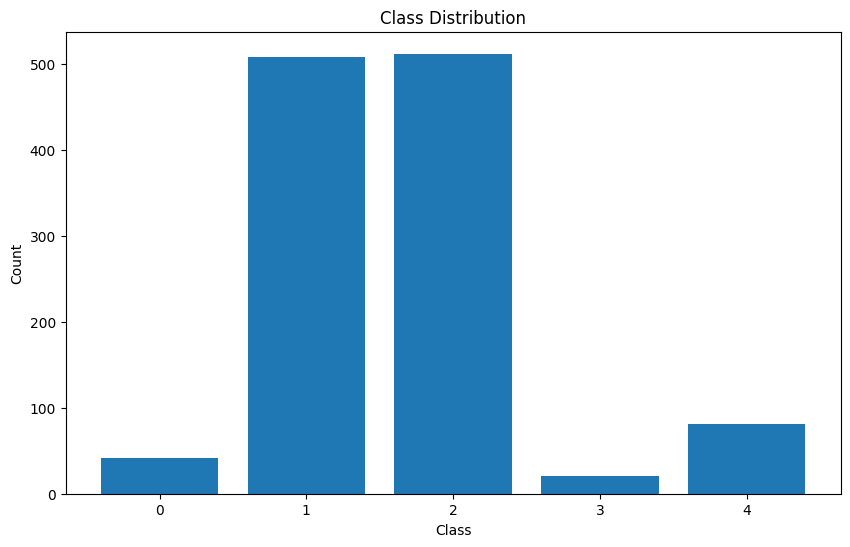

In [ ]:
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10, 6))
plt.bar(unique, counts)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

As shown, it appears the classes for rain and sun have much more data in comparison to the other classes. This class imbalance can cause my accuracy metric to be misleading, resulting in many false negatives for the less frequent classes. The model may learn to predict the majority classes (rain and sun) most of the time simply because those dominate the dataset.

While this can boost overall accuracy, it means the model could effectively ignore the minority classes like drizzle, snow, or fog, failing to detect them when they actually occur. This leads to poor recall for rare weather events, which could be especially problematic if predicting them accurately is important for planning and safety.

Therefore, it's crucial to evaluate the model using more balanced metrics like precision, recall, F1-score, and confusion matrices to understand its true performance across all classes.

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)
val_loader = DataLoader(val_dataset, batch_size=32)

# RNN (PyTorch)

The RNN I am using is built from PyTorch. From the input to the hidden layer, pytorch uses a linear transformation. From the hidden state out, it uses tanh as the activation function.

In [ ]:
class WeatherRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, num_layers=2, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        #Uses tanh here
        out, h_n = self.rnn(x)
        out = h_n[-1]
        #No activation here
        out = self.fc(out)
        return out

Epoch 1/20
Train Loss: 1.168
Val Loss: 0.959
Val Accuracy: 64.14%
Epoch 2/20
Train Loss: 1.019
Val Loss: 0.946
Val Accuracy: 64.83%
Epoch 3/20
Train Loss: 0.993
Val Loss: 0.928
Val Accuracy: 65.52%
Epoch 4/20
Train Loss: 0.974
Val Loss: 0.915
Val Accuracy: 64.83%
Epoch 5/20
Train Loss: 0.957
Val Loss: 0.903
Val Accuracy: 66.21%
Epoch 6/20
Train Loss: 0.943
Val Loss: 0.894
Val Accuracy: 65.52%
Epoch 7/20
Train Loss: 0.932
Val Loss: 0.890
Val Accuracy: 66.90%
Epoch 8/20
Train Loss: 0.923
Val Loss: 0.889
Val Accuracy: 65.52%
Epoch 9/20
Train Loss: 0.914
Val Loss: 0.889
Val Accuracy: 66.21%
Epoch 10/20
Train Loss: 0.905
Val Loss: 0.891
Val Accuracy: 64.14%
Epoch 11/20
Train Loss: 0.897
Val Loss: 0.894
Val Accuracy: 64.83%
Epoch 12/20
Train Loss: 0.889
Val Loss: 0.897
Val Accuracy: 64.83%
Epoch 13/20
Train Loss: 0.882
Val Loss: 0.901
Val Accuracy: 64.14%
Epoch 14/20
Train Loss: 0.875
Val Loss: 0.905
Val Accuracy: 64.14%
Epoch 15/20
Train Loss: 0.868
Val Loss: 0.908
Val Accuracy: 64.14%
Epoc

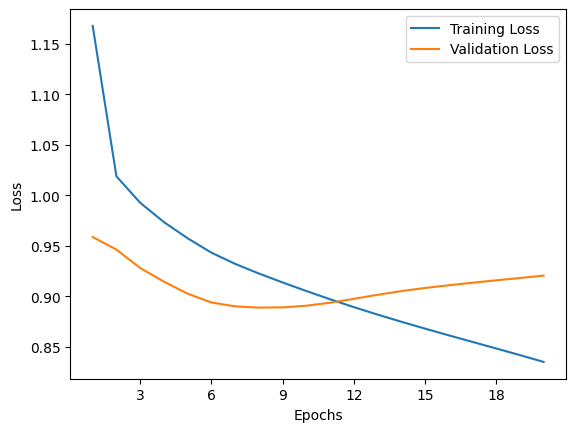

In [ ]:
input_size = X_train.shape[2]
model = WeatherRNN(input_size=input_size, hidden_size=64, num_classes=5)

#defining loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss/len(train_loader)
    train_losses.append(avg_train_loss)

    #evaluation on validation set
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    avg_val_loss = val_loss/len(val_loader)
    val_accuracy = 100 * correct/total
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {avg_train_loss:.3f}")
    print(f"Val Loss: {avg_val_loss:.3f}")
    print(f"Val Accuracy: {val_accuracy:.2f}%")

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# Compute metrics
acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print("\n")
print(f"Test Accuracy : {acc:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall   : {recall:.4f}")
print(f"Test F1 Score : {f1:.4f}")

plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()


# Testing
Lets now evaluate the models performance on the test data set.

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# Compute metrics
test_f1 = f1_score(all_labels, all_preds, average='weighted')
test_precision = precision_score(all_labels, all_preds, average='weighted')
test_recall = recall_score(all_labels, all_preds, average='weighted')
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

Test Accuracy: 0.6096
Test Precision: 0.5577
Test Recall: 0.6096
Test F1 Score: 0.5743


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Evaluation
The vanilla RNN model achieved a test accuracy of around 60% with a precision of 53%, Recall of 60.3% and F1 of around 56.3%. While the overall accuracy is significantly better than randomly guessing, which would be around 20% for a 5-class problem, the low precision and f1 scores suggest that the model is struggling to distinguish less frequent classes reliably. I believe this is most likely caused by the imbalance in the dataset, where rain and sun dominate the labels, causing the model to favor these majority classes.

# LSTM Implementation

In [ ]:
class WeatherLSTM(nn.Module):
  def __init__(self, input_size, hidden_size, num_classes):
    super().__init__()
    self.lstm = nn.LSTM(input_size, hidden_size, num_layers=2, batch_first=True)
    self.fc = nn.Linear(hidden_size, num_classes)

  def forward(self, x):
    out, (h_n, c_n) = self.lstm(x)
    out = h_n[-1]
    out = self.fc(out)
    return out

Epoch 1/20
Train Loss: 1.349
Val Loss: 1.021
Val Accuracy: 60.00%
Epoch 2/20
Train Loss: 1.044
Val Loss: 0.967
Val Accuracy: 62.07%
Epoch 3/20
Train Loss: 1.028
Val Loss: 0.951
Val Accuracy: 62.76%
Epoch 4/20
Train Loss: 1.017
Val Loss: 0.947
Val Accuracy: 63.45%
Epoch 5/20
Train Loss: 1.008
Val Loss: 0.945
Val Accuracy: 64.14%
Epoch 6/20
Train Loss: 0.999
Val Loss: 0.945
Val Accuracy: 65.52%
Epoch 7/20
Train Loss: 0.990
Val Loss: 0.943
Val Accuracy: 66.21%
Epoch 8/20
Train Loss: 0.981
Val Loss: 0.938
Val Accuracy: 65.52%
Epoch 9/20
Train Loss: 0.971
Val Loss: 0.928
Val Accuracy: 64.83%
Epoch 10/20
Train Loss: 0.959
Val Loss: 0.919
Val Accuracy: 62.76%
Epoch 11/20
Train Loss: 0.948
Val Loss: 0.911
Val Accuracy: 63.45%
Epoch 12/20
Train Loss: 0.937
Val Loss: 0.906
Val Accuracy: 63.45%
Epoch 13/20
Train Loss: 0.928
Val Loss: 0.904
Val Accuracy: 64.14%
Epoch 14/20
Train Loss: 0.919
Val Loss: 0.904
Val Accuracy: 65.52%
Epoch 15/20
Train Loss: 0.912
Val Loss: 0.904
Val Accuracy: 64.83%
Epoc

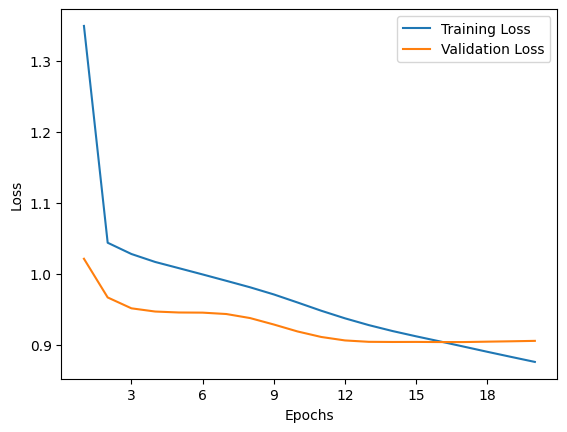

In [ ]:
input_size = X_train.shape[2]

model_lstm = WeatherLSTM(input_size, 64, 5)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_lstm.parameters(), lr=0.001)

epochs = 20

lstm_train_losses = []
lstm_val_losses = []

for epoch in range(epochs):
    model_lstm.train()
    lstm_train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model_lstm(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        lstm_train_loss += loss.item()

    avg_lstm_train_loss = lstm_train_loss/len(train_loader)
    lstm_train_losses.append(avg_lstm_train_loss)

    #evaluation on validation set
    model_lstm.eval()
    lstm_val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model_lstm(X_batch)
            loss = criterion(outputs, y_batch)
            lstm_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    avg_lstm_val_loss = lstm_val_loss/len(val_loader)
    val_accuracy = 100 * correct/total
    lstm_val_losses.append(avg_lstm_val_loss)


    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {avg_lstm_train_loss:.3f}")
    print(f"Val Loss: {avg_lstm_val_loss:.3f}")
    print(f"Val Accuracy: {val_accuracy:.2f}%")

model_lstm.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model_lstm(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# Compute metrics
acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print("\n")
print(f"Test Accuracy : {acc:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall   : {recall:.4f}")
print(f"Test F1 Score : {f1:.4f}")



plt.plot(range(1, epochs + 1), lstm_train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), lstm_val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()



# GRU Implementation

For this implementation, we'll use the nn.GRU function from PyTorch. This will use the same inputs as the previous models

In [ ]:
class WeatherGRU(nn.Module):
  def __init__(self, input_size, hidden_size, num_classes):
    super().__init__()
    self.gru = nn.GRU(input_size, hidden_size, num_layers=2, batch_first=True)
    self.fc = nn.Linear(hidden_size, num_classes)

  def forward(self, x):
      out, h_n = self.gru(x)
      # h_n: (num_layers, batch, hidden_size)
      last_hidden = h_n[-1]
      out = self.fc(last_hidden)
      return out

Epoch 1/20
Train Loss: 1.232
Val Loss: 0.979
Val Accuracy: 64.14%
Epoch 2/20
Train Loss: 1.021
Val Loss: 0.956
Val Accuracy: 62.76%
Epoch 3/20
Train Loss: 1.000
Val Loss: 0.941
Val Accuracy: 62.76%
Epoch 4/20
Train Loss: 0.983
Val Loss: 0.927
Val Accuracy: 63.45%
Epoch 5/20
Train Loss: 0.966
Val Loss: 0.911
Val Accuracy: 63.45%
Epoch 6/20
Train Loss: 0.951
Val Loss: 0.896
Val Accuracy: 63.45%
Epoch 7/20
Train Loss: 0.938
Val Loss: 0.886
Val Accuracy: 64.83%
Epoch 8/20
Train Loss: 0.928
Val Loss: 0.879
Val Accuracy: 64.83%
Epoch 9/20
Train Loss: 0.919
Val Loss: 0.875
Val Accuracy: 64.83%
Epoch 10/20
Train Loss: 0.912
Val Loss: 0.873
Val Accuracy: 64.14%
Epoch 11/20
Train Loss: 0.905
Val Loss: 0.871
Val Accuracy: 65.52%
Epoch 12/20
Train Loss: 0.898
Val Loss: 0.871
Val Accuracy: 65.52%
Epoch 13/20
Train Loss: 0.892
Val Loss: 0.871
Val Accuracy: 65.52%
Epoch 14/20
Train Loss: 0.886
Val Loss: 0.872
Val Accuracy: 66.21%
Epoch 15/20
Train Loss: 0.880
Val Loss: 0.874
Val Accuracy: 65.52%
Epoc

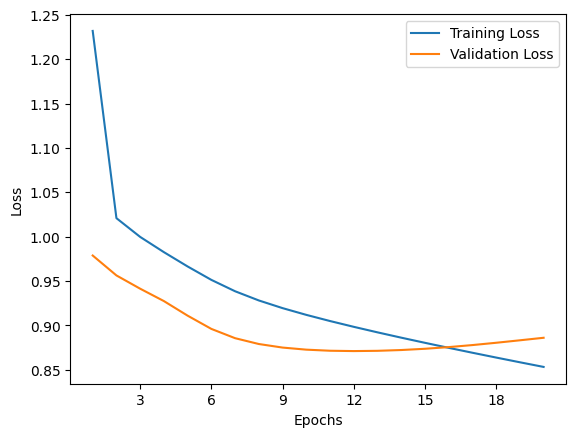

In [ ]:
input_size = X_train.shape[2]

model_gru = WeatherGRU(input_size, 64, 5)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_gru.parameters(), lr=0.001)

epochs = 20

gru_train_losses = []
gru_val_losses = []

for epoch in range(epochs):
    model_gru.train()
    gru_train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model_gru(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        gru_train_loss += loss.item()

    avg_gru_train_loss = gru_train_loss/len(train_loader)
    gru_train_losses.append(avg_gru_train_loss)

    #evaluation on validation set
    model_gru.eval()
    gru_val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model_gru(X_batch)
            loss = criterion(outputs, y_batch)
            gru_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    avg_gru_val_loss = gru_val_loss/len(val_loader)
    val_accuracy = 100 * correct/total
    gru_val_losses.append(avg_gru_val_loss)


    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {avg_gru_train_loss:.3f}")
    print(f"Val Loss: {avg_gru_val_loss:.3f}")
    print(f"Val Accuracy: {val_accuracy:.2f}%")

model_gru.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model_gru(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# Compute metrics
acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print("\n")
print(f"Test Accuracy : {acc:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall   : {recall:.4f}")
print(f"Test F1 Score : {f1:.4f}")



plt.plot(range(1, epochs + 1), gru_train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), gru_val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()



# Evaluation
The tests for each model are:\
Vanilla RNN
- Test Accuracy : 0.6096
- Test Precision: 0.5577
- Test Recall   : 0.6096
- Test F1 Score : 0.5743

LSTM
- Test Accuracy : 0.6233
- Test Precision: 0.5564
- Test Recall   : 0.6233
- Test F1 Score : 0.5816

GRU
- Test Accuracy : 0.6575
- Test Precision: 0.5982
- Test Recall   : 0.6575
- Test F1 Score : 0.6196

The GRU model outperformed the LSTM and the Vanilla RNN models. This is expected because the Vanilla RNN model is not good at remembering long-term dependencies. Since my model is trying to predict patterns over 7 days, the Vanilla RNN cannot model that reliably. For the LSTM model, it is designed to fix the vanishing gradient problem present in the Vanilla RNN, but requires a large amount of data to train effectively. The weather dataset isn't super huge or clean, which could be cause it to slightly underperform in comparison. Overall however, all models didn't perform too highly on this dataset. If there were more entries and more balance between classes, I believe these models would perform better.


# Can a Traditional Feed-Forward Network Solve This Problem?

If I were to use a feed-forward network on this dataset, I don't think it would perform nearly as well as any of the models above. A traditional feed-forward network would view all the input features as independent, and since this dataset is sequential (each previous day has an impact on the next and so on), it won't see patterns that involve previous dates.

If I were to try to flatten the dataset, it could potentially learn some patterns, but it would still perform worse than the Vanilla RNN, LSTM, and GRU models.

# References

1. https://docs.pytorch.org/docs/stable/generated/torch.nn.RNN.html

2. https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html

3. https://docs.pytorch.org/docs/stable/generated/torch.nn.GRU.html

4. https://www.geeksforgeeks.org/deep-learning/implementing-recurrent-neural-networks-in-pytorch/


